# Análisis exploratorio de los datos

### Librerias requeridas

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')


In [7]:
df = pd.read_csv("../data/raw/bs140513_032310.csv",delimiter=";")

In [8]:
print("Tamaño del dataset: ",df.shape)
df.info()

Tamaño del dataset:  (594643, 10)
<class 'pandas.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  str    
 2   age          594643 non-null  str    
 3   gender       594643 non-null  str    
 4   zipcodeOri   594643 non-null  str    
 5   merchant     594643 non-null  str    
 6   zipMerchant  594643 non-null  str    
 7   category     594643 non-null  str    
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 45.4 MB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,594643.0,94.986827,51.053632,0.0,52.00,97.0,139.00,179.00
amount,594643.0,37.890135,111.402831,0.0,13.74,26.9,42.54,8329.96
fraud,594643.0,0.012108,0.109369,0.0,0.00,0.0,0.00,1.00


In [10]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0]

Series([], dtype: int64)

In [11]:
df['fraud'].value_counts()

fraud
0    587443
1      7200
Name: count, dtype: int64

In [12]:
# En porcentaje
df['fraud'].value_counts(normalize=True) * 100

fraud
0    98.789189
1     1.210811
Name: proportion, dtype: float64

In [13]:
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


VALORES NULOS: 

In [14]:
df.isnull().sum()

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

In [15]:
valores_unicos = {col: df[col].unique() for col in df.columns}
for col, vals in valores_unicos.items():
    print(f"{col}: {vals}")

step: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179]
customer: <StringArray>
[''C1093826151'',  ''C352968107'', ''C2054744914'', ''C1760612790'',
  ''C757503768'', ''C1315400589'',  ''C765155274'',  ''C202531238'',
  ''C105845174'',   ''C39858251'',
 ...
 ''C1468001998'',  ''C762865358'',   ''C20027851'', ''C123918

ANÁLISIS UNIVARIADO: 

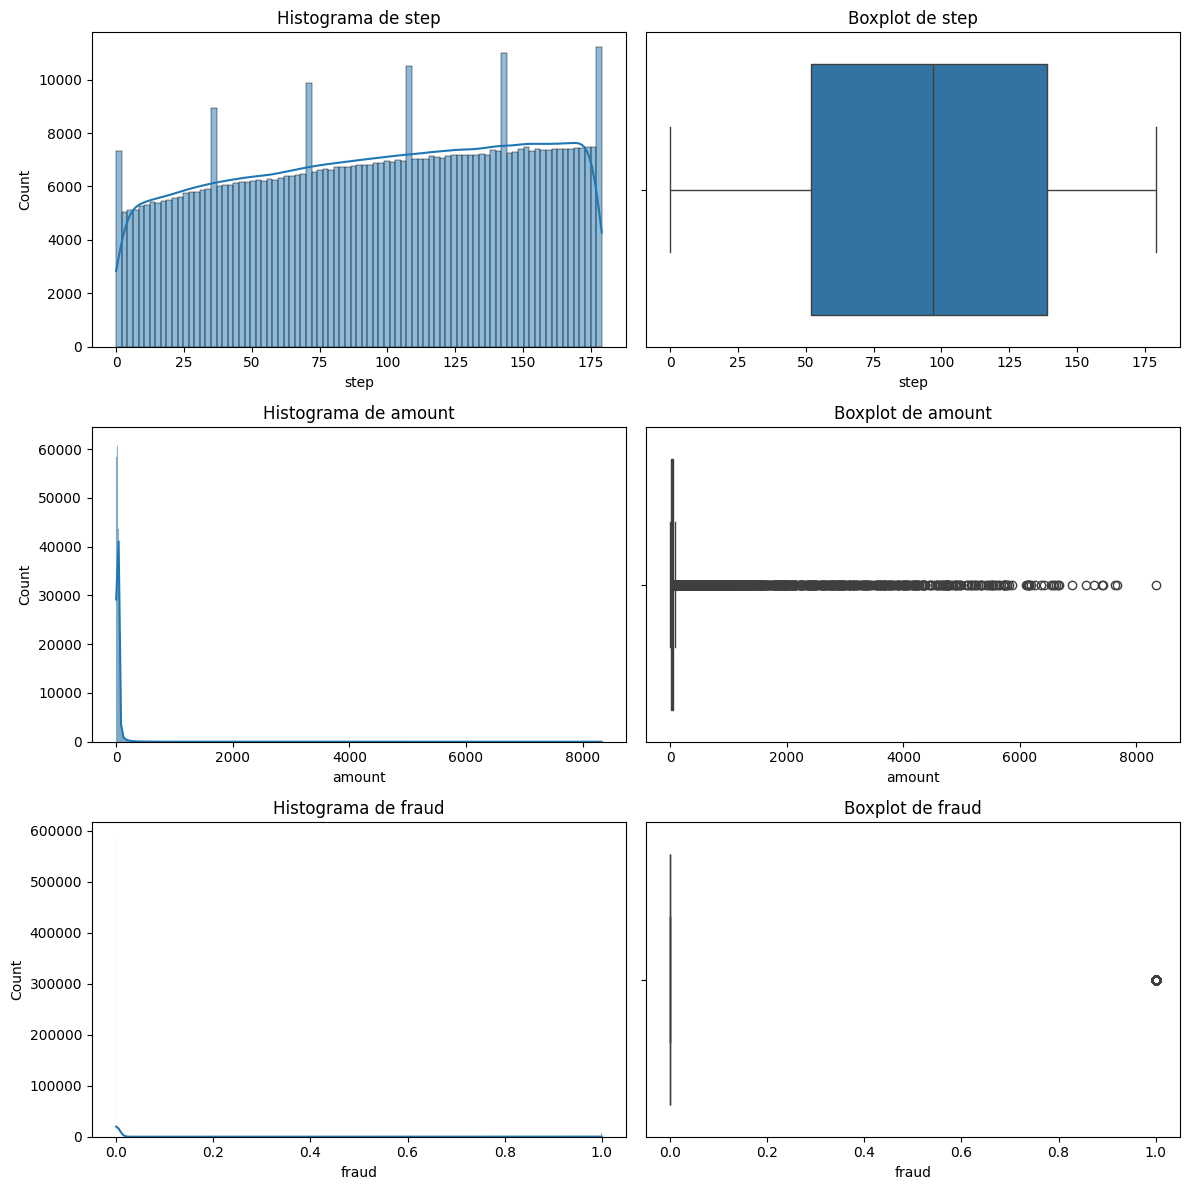

In [16]:
variables_numericas = df.select_dtypes(include=[np.number]).columns

#Voy a crear subgráficos con dos columnas, a la izquierda el histograma y a la derecha el boxplot
fig, axes = plt.subplots(nrows=len(variables_numericas), ncols=2, figsize=(12, 4 * len(variables_numericas)))

for i, col in enumerate(variables_numericas):
    # Histograma con densidad
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

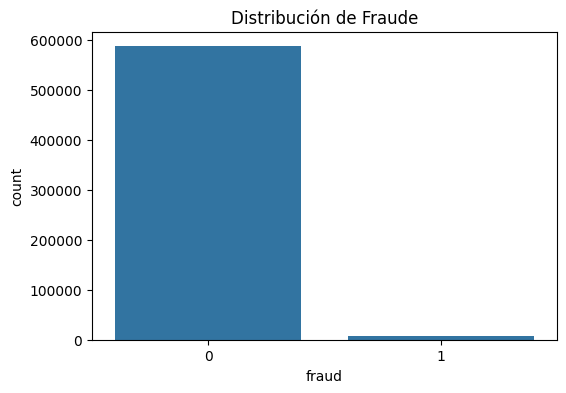

In [17]:
# Visualización
plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title('Distribución de Fraude')
plt.show()

VARIABLES CATEGÓRICAS

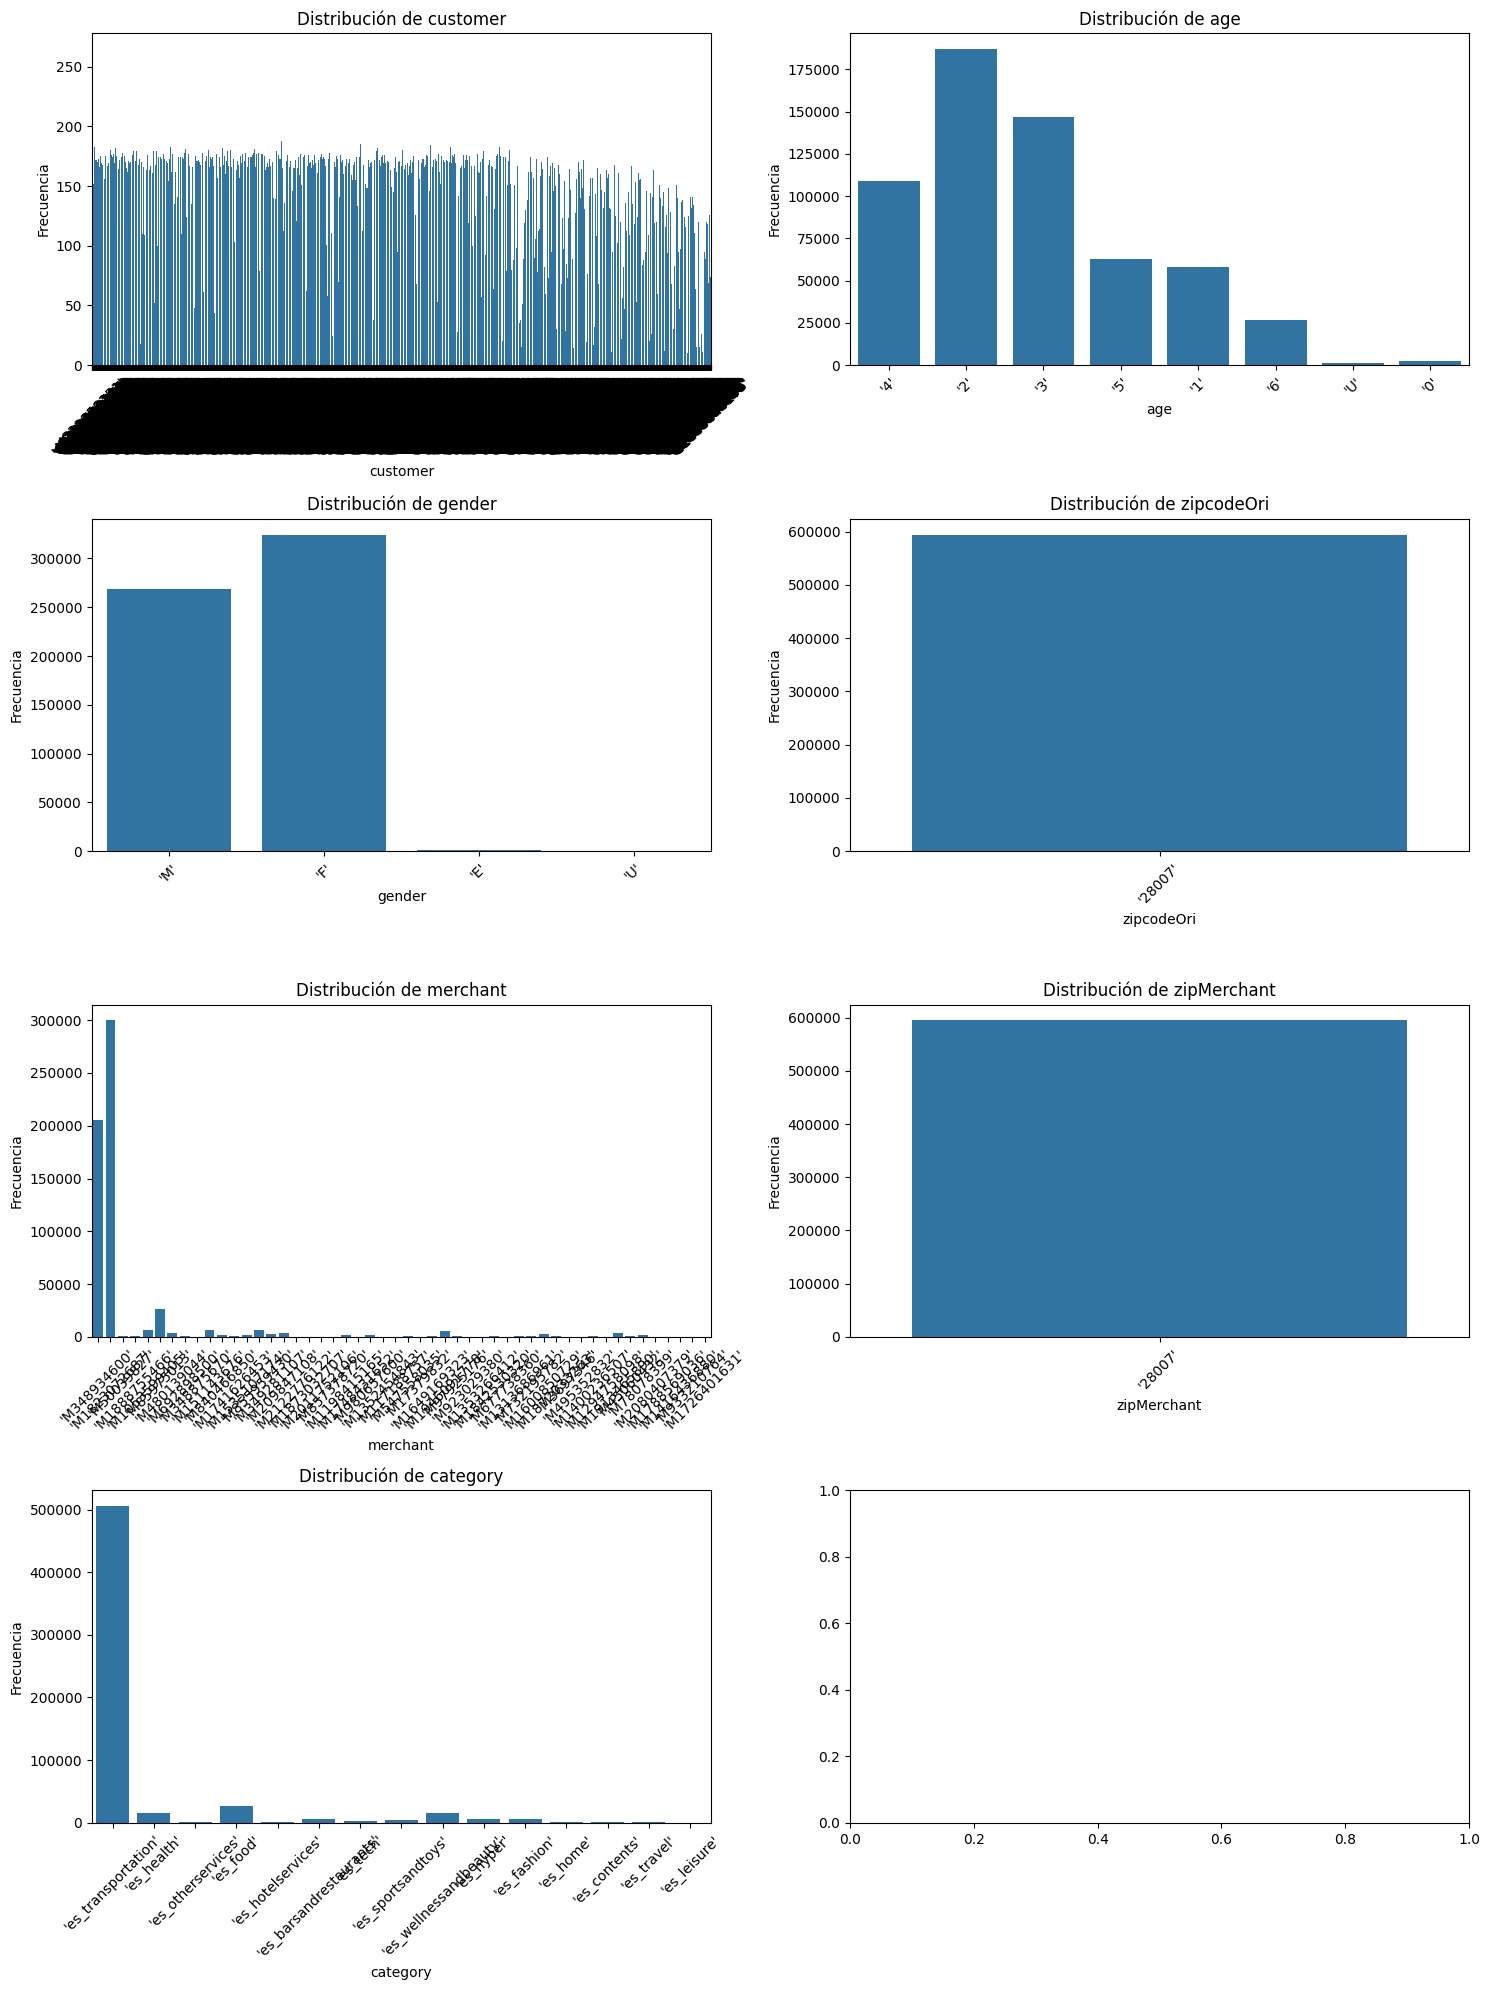

In [18]:
cols_categoricas = df.select_dtypes(include=['object']).columns.tolist()

#Me ha ayudado chatgpt para representar los histogramas y para que aparezcan dos graficas por cada fila: 
fig, axs = plt.subplots(nrows=(len(cols_categoricas) + 1) // 2, ncols=2, figsize=(15, 5 * ((len(cols_categoricas) + 1) // 2)))

for ax, col in zip(axs.flat, cols_categoricas):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ANÁLISIS BIVARIADO 

step     -0.011898
amount    0.489967
Name: fraud, dtype: float64


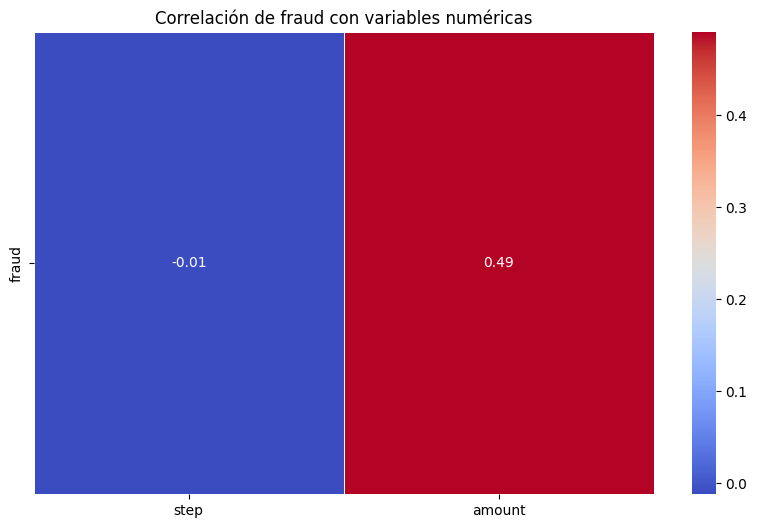

In [19]:
#Voy a ver la correlacion de las variables numéricas con fraud 

df['fraud'] = pd.to_numeric(df['fraud'], errors='coerce')
columnas_numericas = df.select_dtypes(include=['number']).columns.tolist()
matriz_correlacion = df[columnas_numericas].corr()

correlacion_is_subscribed = matriz_correlacion['fraud'].drop('fraud')
print(correlacion_is_subscribed)

plt.figure(figsize=(10, 6))
sns.heatmap(correlacion_is_subscribed.to_frame().T, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlación de fraud con variables numéricas")
plt.show()

## Categoria amount

Miramos a ver como se distribuye la categoria de amount buscando posibles outliers

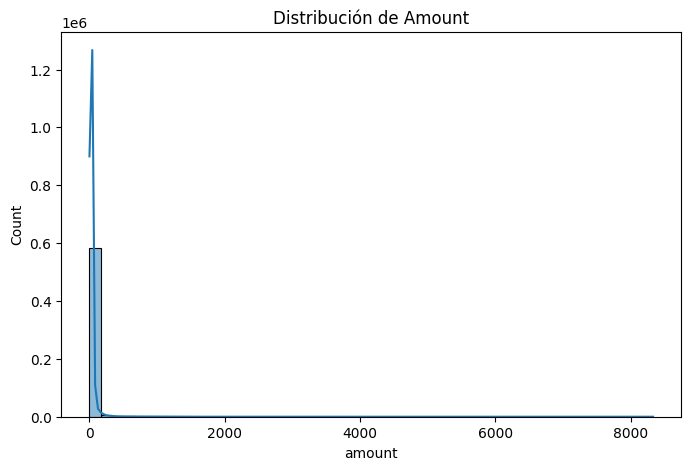

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribución de Amount')
plt.show()

Vemos claramente que existen outliers ya que la mayoria de los datos se encuentran siendo cercanos a 0, miramos ahora a ver los valores de amount como se relaccionan con el fraude

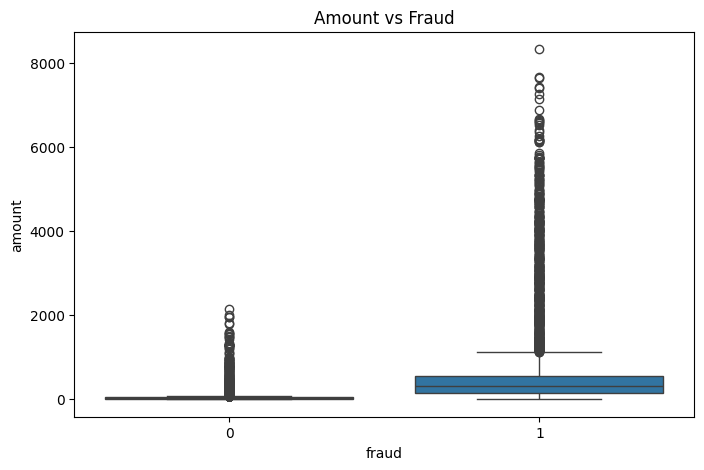

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud', y='amount', data=df)
plt.title('Amount vs Fraud')
plt.show()

Podemos apreciar que los valores mas altos son aquellos que son mas suceptibles para ser fraude lo que deberemos tener en cuenta en un futuro

## División variables categoricas

In [22]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant',
       'category'],
      dtype='str')

## Relacción de merchants y clients

In [23]:
# Número de clientes únicos
df['customer'].nunique()

# Número de comercios únicos
df['merchant'].nunique()

50

In [24]:
fraud_by_merchant = df.groupby('merchant')['fraud'].mean().sort_values(ascending=False)

fraud_by_merchant.head(10)

merchant
'M1294758098'    0.963351
'M3697346'       0.941558
'M1873032707'    0.864000
'M732195782'     0.851974
'M980657600'     0.832109
'M1353266412'    0.820513
'M857378720'     0.754098
'M2080407379'    0.750000
'M2011752106'    0.680328
'M17379832'      0.631206
Name: fraud, dtype: float64

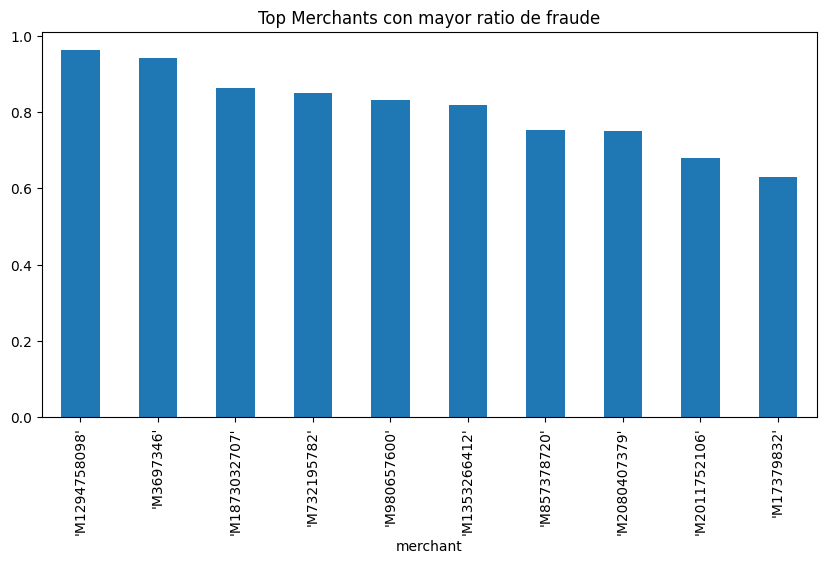

In [25]:
top_merchants = fraud_by_merchant.head(10)

plt.figure(figsize=(10,5))
top_merchants.plot(kind='bar')
plt.title('Top Merchants con mayor ratio de fraude')
plt.show()

Podemos ver que existen unos merchants con un mayor indice de fraude lo que nos indica que algo puede estar pasando con esos merchants, tendriamos que realizar un analisis de los datos de amount y que porcentaje representa el frsude por cada merchant.

### Análisis del fraude por merchant

In [26]:
merchant_analysis = df.groupby('merchant').agg({
    'fraud': ['count', 'sum', 'mean'],
    'amount': ['sum', 'mean']
})

# Aplanar columnas
merchant_analysis.columns = [
    'n_transactions',
    'n_fraud',
    'fraud_ratio',
    'total_amount',
    'avg_amount'
]

# Calcular amount fraudulento
fraud_amount = df[df['fraud'] == 1].groupby('merchant')['amount'].sum()

merchant_analysis['fraud_amount'] = fraud_amount

# Rellenar NaN (merchants sin fraude)
merchant_analysis['fraud_amount'] = merchant_analysis['fraud_amount'].fillna(0)

merchant_analysis.head()

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M1053599405',6821,0,0.000000,703056.31,103.072322,0.00
'M117188757',21,0,0.000000,2207.15,105.102381,0.00
'M1198415165',1580,358,0.226582,149504.20,94.622911,80191.83
'M1294758098',191,184,0.963351,55326.42,289.667120,54808.34
'M1313686961',527,0,0.000000,23500.82,44.593586,0.00


#### Merchants con mas fraude por ratio

In [27]:
merchant_analysis.sort_values('fraud_ratio', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M1294758098',191,184,0.963351,55326.42,289.667120,54808.34
'M3697346',308,290,0.941558,88840.32,288.442597,87527.64
'M1873032707',250,216,0.864000,94059.33,376.237320,90653.68
'M732195782',608,518,0.851974,1413661.65,2325.101398,1350979.31
'M980657600',1769,1472,0.832109,530635.69,299.963646,505311.62
'M1353266412',78,64,0.820513,29470.62,377.828462,28180.77
'M857378720',122,92,0.754098,43460.67,356.235000,39963.37
'M2080407379',48,36,0.750000,110376.59,2299.512292,103583.41
'M2011752106',244,166,0.680328,78953.83,323.581270,70246.52


#### Merchant con mas fraude por volumen 

In [28]:
merchant_analysis.sort_values('fraud_amount', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M732195782',608,518,0.851974,1413661.65,2325.101398,1350979.31
'M480139044',3508,1634,0.465792,858388.22,244.694475,664804.39
'M980657600',1769,1472,0.832109,530635.69,299.963646,505311.62
'M2080407379',48,36,0.750000,110376.59,2299.512292,103583.41
'M2122776122',341,200,0.586510,109999.72,322.579824,93889.68
'M1873032707',250,216,0.864000,94059.33,376.237320,90653.68
'M3697346',308,290,0.941558,88840.32,288.442597,87527.64
'M495352832',69,24,0.347826,111691.89,1618.723043,83381.34
'M1198415165',1580,358,0.226582,149504.20,94.622911,80191.83


#### Merchant mas activos

In [29]:
merchant_analysis.sort_values('n_transactions', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
merchant,,,,,,
'M1823072687',299693,0,0.000000,8077669.06,26.953146,0.00
'M348934600',205426,0,0.000000,5539423.40,26.965542,0.00
'M85975013',26254,0,0.000000,973246.41,37.070405,0.00
'M1053599405',6821,0,0.000000,703056.31,103.072322,0.00
'M151143676',6373,120,0.018829,276977.04,43.461014,19691.12
'M855959430',6098,280,0.045917,280327.63,45.970421,47391.52
'M1946091778',5343,0,0.000000,304913.51,57.067848,0.00
'M1913465890',3988,0,0.000000,416513.34,104.441660,0.00
'M209847108',3814,106,0.027792,237961.65,62.391623,24524.59


#### Merchants por volumen de fraude

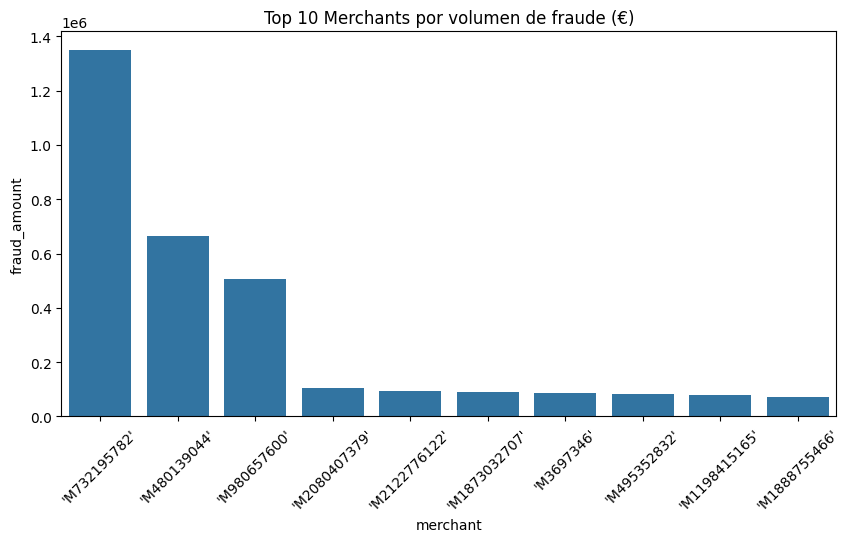

In [30]:
top_merchants = merchant_analysis.sort_values('fraud_amount', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_merchants.index, y=top_merchants['fraud_amount'])
plt.xticks(rotation=45)
plt.title('Top 10 Merchants por volumen de fraude (€)')
plt.show()

### Análisis de fraude por cliente

In [31]:
customer_analysis = df.groupby('customer').agg({
    'fraud': ['count', 'sum', 'mean'],
    'amount': ['sum', 'mean']
})

customer_analysis.columns = [
    'n_transactions',
    'n_fraud',
    'fraud_ratio',
    'total_amount',
    'avg_amount'
]

# Amount fraudulento
fraud_amount_cust = df[df['fraud'] == 1].groupby('customer')['amount'].sum()

customer_analysis['fraud_amount'] = fraud_amount_cust
customer_analysis['fraud_amount'] = customer_analysis['fraud_amount'].fillna(0)

customer_analysis.head()

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C1000148617',131,1,0.007634,4597.04,35.091908,323.64
'C100045114',109,5,0.045872,9846.65,90.336239,5004.46
'C1000699316',94,0,0.000000,3586.56,38.154894,0.00
'C1001065306',30,11,0.366667,6142.64,204.754667,4465.43
'C1002658784',131,0,0.000000,4487.18,34.253282,0.00


#### Clientes mas fraudulentos por ratio

In [32]:
customer_analysis.sort_values('fraud_ratio', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C910454738',92,87,0.945652,37795.51,410.820761,37143.84
'C2004941826',126,119,0.944444,64751.08,513.897460,64165.54
'C381007057',100,89,0.890000,51388.87,513.888700,50245.22
'C1572610482',101,89,0.881188,58687.13,581.060693,58203.13
'C617723960',46,40,0.869565,23823.87,517.910217,23443.52
'C2113737065',91,79,0.868132,39340.93,432.317912,38150.95
'C2060410910',13,11,0.846154,7305.33,561.948462,7213.91
'C483912131',98,80,0.816327,50462.72,514.925714,49490.29
'C1809646275',5,4,0.800000,1351.55,270.310000,1286.79


#### Clientes con mayor impacto economico 

In [33]:
customer_analysis.sort_values('fraud_amount', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C806399525',237,125,0.527426,83755.49,353.398692,80324.04
'C2004941826',126,119,0.944444,64751.08,513.897460,64165.54
'C1849046345',171,127,0.742690,60693.04,354.930058,59066.72
'C1572610482',101,89,0.881188,58687.13,581.060693,58203.13
'C1350963410',191,144,0.753927,56217.36,294.331728,54274.78
'C1978250683',265,110,0.415094,55965.05,211.188868,50495.56
'C381007057',100,89,0.890000,51388.87,513.888700,50245.22
'C483912131',98,80,0.816327,50462.72,514.925714,49490.29
'C1275518867',252,114,0.452381,52964.37,210.176071,49229.18


#### Clientes mas activos

In [34]:
customer_analysis.sort_values('n_transactions', ascending=False).head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C1978250683',265,110,0.415094,55965.05,211.188868,50495.56
'C1275518867',252,114,0.452381,52964.37,210.176071,49229.18
'C806399525',237,125,0.527426,83755.49,353.398692,80324.04
'C515668508',205,44,0.214634,35775.78,174.516000,31062.65
'C1338396147',195,16,0.082051,15825.04,81.154051,8890.21
'C1896850232',192,6,0.031250,8584.87,44.712865,2667.66
'C1350963410',191,144,0.753927,56217.36,294.331728,54274.78
'C980876590',189,0,0.000000,7171.30,37.943386,0.00
'C582688427',188,0,0.000000,6156.10,32.745213,0.00


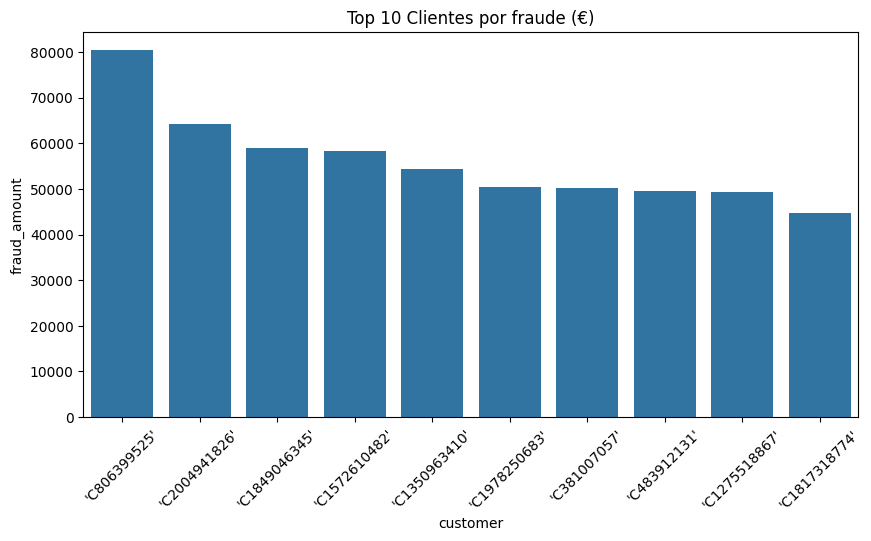

In [35]:
top_customers = customer_analysis.sort_values('fraud_amount', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.index, y=top_customers['fraud_amount'])
plt.xticks(rotation=45)
plt.title('Top 10 Clientes por fraude (€)')
plt.show()

### Deteccion de clientes con comportamiento notable

In [36]:
suspicious_customers = customer_analysis[
    (customer_analysis['n_transactions'] < 10) &
    (customer_analysis['fraud_ratio'] > 0.5)
]

suspicious_customers.head(10)

,n_transactions,n_fraud,fraud_ratio,total_amount,avg_amount,fraud_amount
customer,,,,,,
'C1233811793',7,5,0.714286,1339.31,191.3300,1054.56
'C1809646275',5,4,0.800000,1351.55,270.3100,1286.79
'C650117238',8,5,0.625000,2917.90,364.7375,2807.99
